# Director Skill Sets Table 7 - Cessation dates only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from sklearn.preprocessing import StandardScaler

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] CAPM CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
firm_input_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[2] Firm Level Wrangling\Firm level Iterative\Firm Lev + Fin\City level\city_lev_output"
filtering_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_filtering"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm00 = pd.read_pickle(rf"{import_folder_path}\Director Level_MF_CAR.pkl")
dirFirm00 = dirFirm00.loc[ dirFirm00["date_source"] == "Cessation Date"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")
firm = pd.read_pickle(rf"{firm_input_folder_path}\Main_Firm_COMPLETE.pkl")

In [4]:
# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm00 = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [5]:
firm_col = [
    "AsOnDate", "Symbol",

    "PercentWomenDir", "PercentBusyDir",
    "LnBoardSize", "PercentIndep",
    "Promoters_percent", "NonpromoterInstitutions_percent", "RD to Assets",
    "ln_marcap", "ln_rdtoassets", "Debt to equity ratio", # control variables
    
    "FamilyOwnedFamilyCeoChair25", "promoterholding25", "HasFamilyChairmanAndCEO",
]

firm2 = firm[firm_col].copy()
dirFirm = dirFirm00.merge(firm2, on = ["AsOnDate", "Symbol"], how = "left")

In [6]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log((dirFirm["CompCountCurrTotalAB"] - 1) + 1).astype("float")

In [7]:
dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)

# PSM

## Verifying and removing those rows with no control data points

In [8]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
# dirFirm.columns.to_list()

In [9]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


dirFirm["NIC_1digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:1])
dirFirm["NIC_1digit"] = dirFirm["NIC_1digit"]

dirFirm.loc[dirFirm["RD to Assets"] == 0, "ln_rdtoassets"] = 0

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013) 
    & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

# psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

# psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
# psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
# psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count         6356.000000            6356.000000
mean             0.025058               0.025058
std              2.161178               2.161178
min             -1.390619              -1.390619
25%             -0.036711              -0.036711
50%             -0.005475              -0.005475
75%              0.029607               0.029607
max            172.196754             172.196754


Top values and their count:  nonwinsorised_120CAR3
0.351552      1
0.354014      1
0.367410      2
0.396294      2
0.458358      1
0.474200      1
0.521145      1
0.556494      1
0.579376      1
172.196754    1
Name: count, dtype: int64





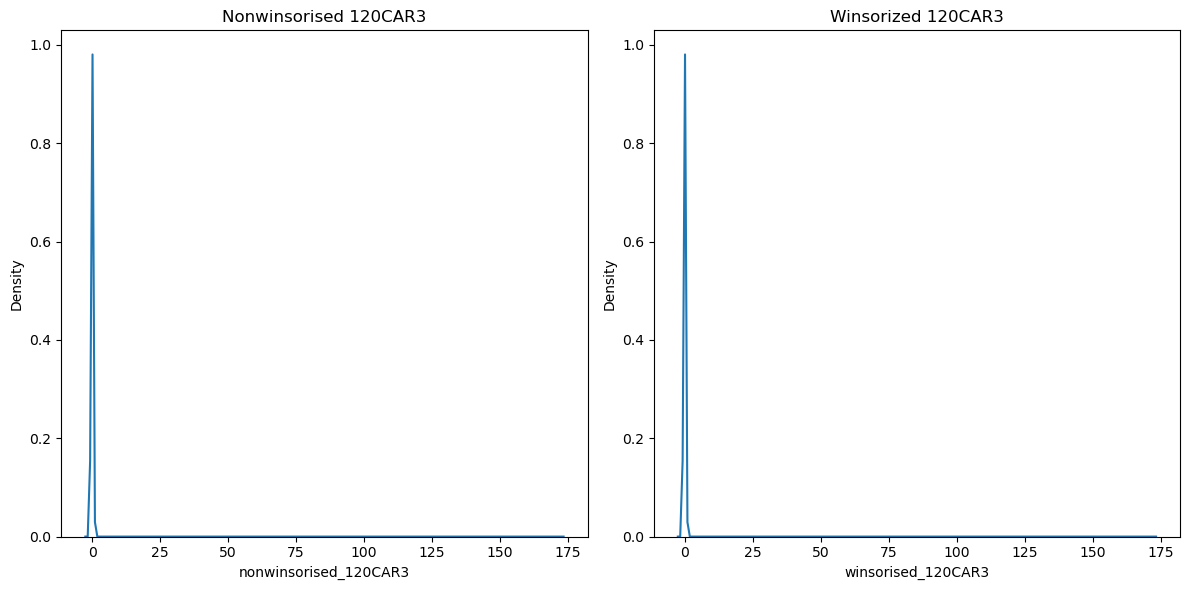

       winsorised_120CAR5  nonwinsorised_120CAR5
count         6356.000000            6356.000000
mean            -0.025158              -0.025158
std              2.162524               2.162524
min             -1.484397              -1.484397
25%             -0.096157              -0.096157
50%             -0.053877              -0.053877
75%             -0.015056              -0.015056
max            172.162555             172.162555


Top values and their count:  nonwinsorised_120CAR5
0.515945      1
0.526163      1
0.577019      2
0.620251      1
0.690441      1
0.825087      1
0.862499      2
0.868369      1
1.325889      2
172.162555    1
Name: count, dtype: int64





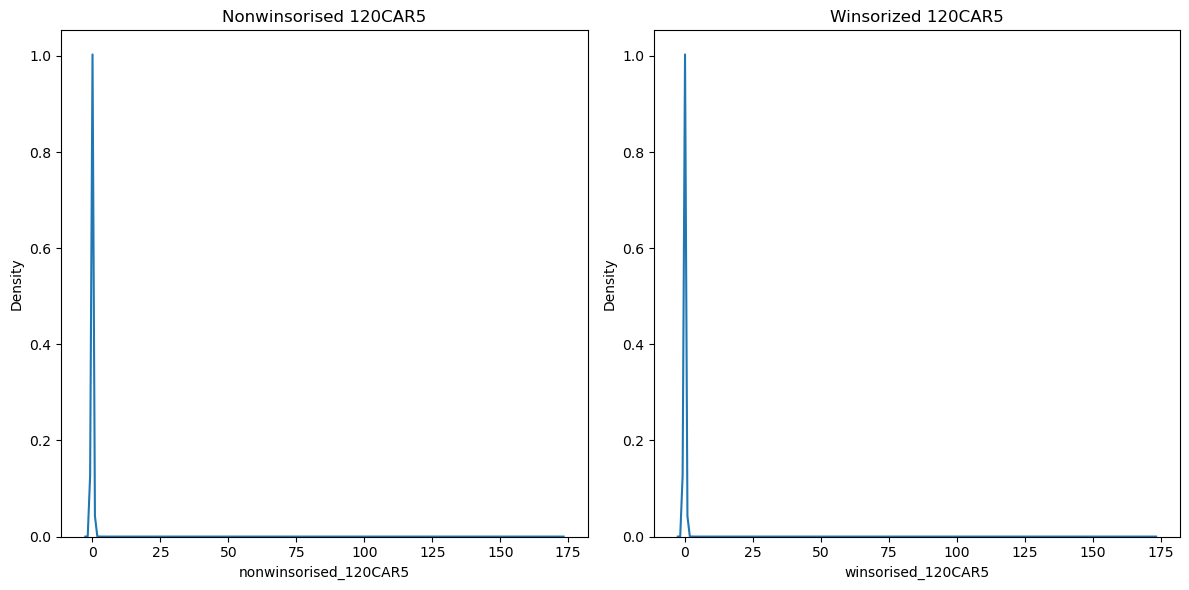

       winsorised_120CAR7  nonwinsorised_120CAR7
count         6353.000000            6353.000000
mean            -0.074123              -0.074123
std              2.164351               2.164351
min             -1.808309              -1.808309
25%             -0.158710              -0.158710
50%             -0.104600              -0.104600
75%             -0.052100              -0.052100
max            172.143174             172.143174


Top values and their count:  nonwinsorised_120CAR7
0.539612      1
0.541790      1
0.580645      2
0.622783      1
0.708274      1
0.780516      2
0.995636      2
1.328174      1
1.640626      1
172.143174    1
Name: count, dtype: int64





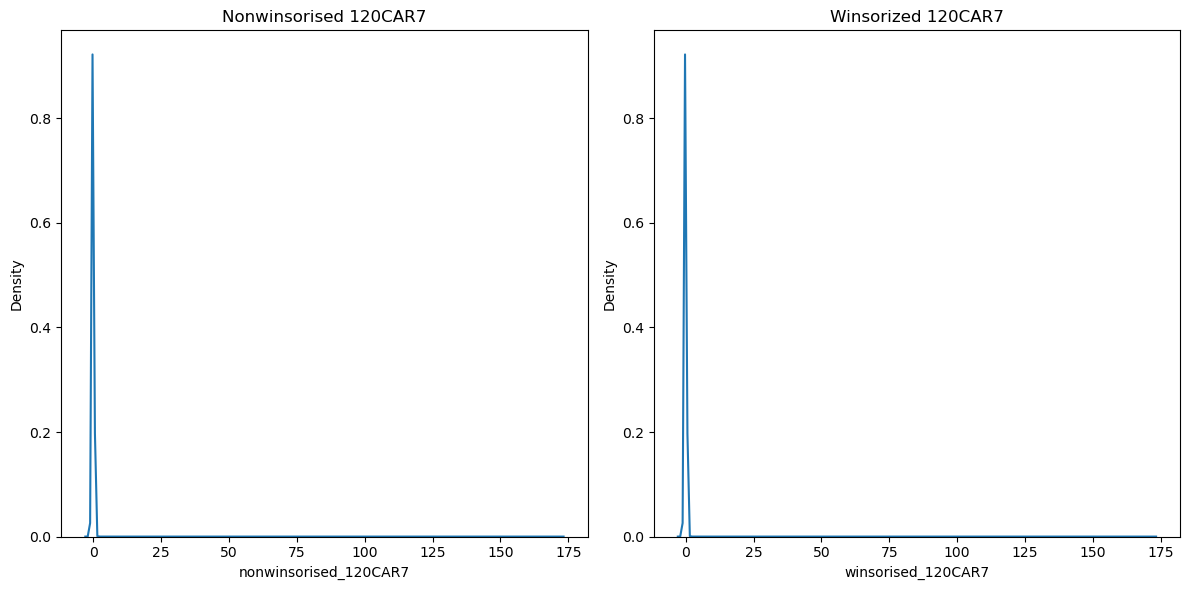

       winsorised_120CAR11  nonwinsorised_120CAR11
count          6352.000000             6352.000000
mean             -0.171533               -0.171533
std               2.168007                2.168007
min              -2.903153               -2.903153
25%              -0.277224               -0.277224
50%              -0.208004               -0.208004
75%              -0.131282               -0.131282
max             171.998594              171.998594


Top values and their count:  nonwinsorised_120CAR11
0.673681      1
0.682899      2
0.719277      1
1.000681      1
1.088694      1
1.157999      1
2.014721      1
2.158702      2
5.807211      1
171.998594    1
Name: count, dtype: int64





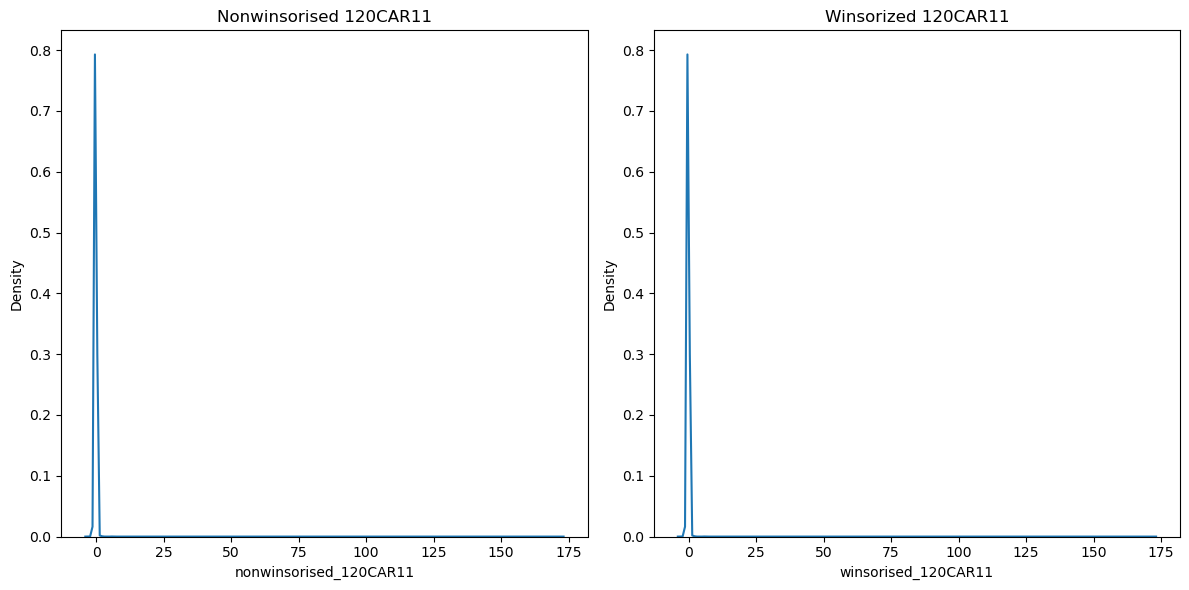

       winsorised_150CAR3  nonwinsorised_150CAR3
count         6338.000000            6338.000000
mean             0.025506               0.025506
std              2.164178               2.164178
min             -1.112824              -1.112824
25%             -0.037102              -0.037102
50%             -0.005638              -0.005638
75%              0.030142               0.030142
max            172.195855             172.195855


Top values and their count:  nonwinsorised_150CAR3
0.358338      1
0.368542      2
0.369703      1
0.402356      2
0.457152      1
0.469128      1
0.519796      1
0.573393      1
0.583729      1
172.195855    1
Name: count, dtype: int64





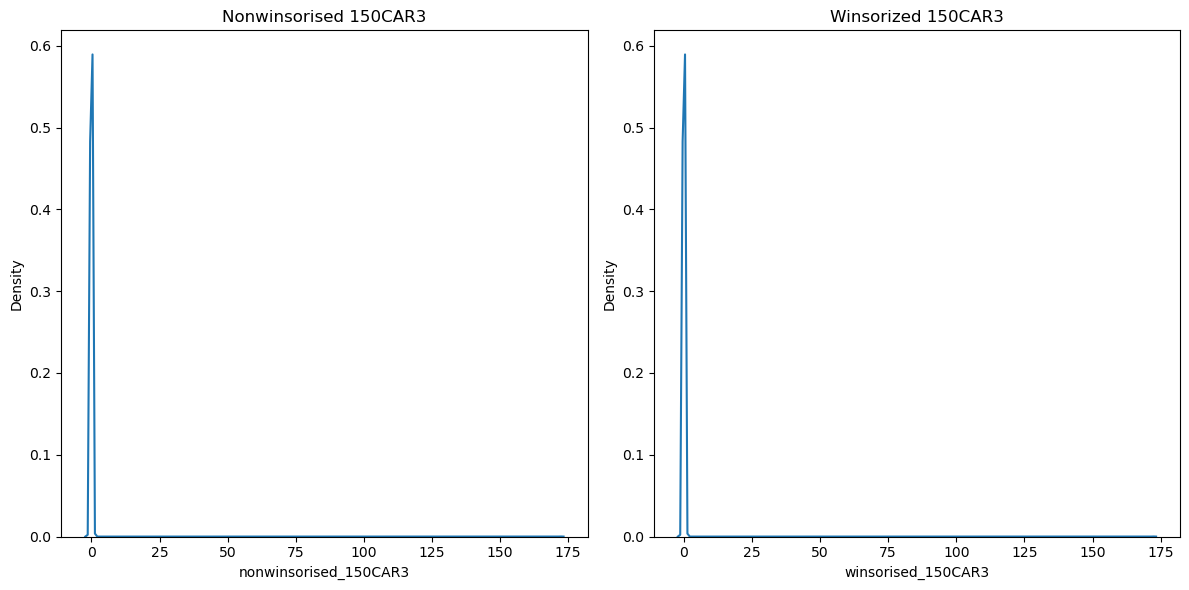

       winsorised_150CAR5  nonwinsorised_150CAR5
count         6338.000000            6338.000000
mean            -0.024776              -0.024776
std              2.165508               2.165508
min             -1.162131              -1.162131
25%             -0.096206              -0.096206
50%             -0.053803              -0.053803
75%             -0.013627              -0.013627
max            172.161791             172.161791


Top values and their count:  nonwinsorised_150CAR5
0.519890      1
0.524806      1
0.581689      2
0.638748      1
0.701324      1
0.856832      1
0.864265      2
0.872016      1
1.340144      2
172.161791    1
Name: count, dtype: int64





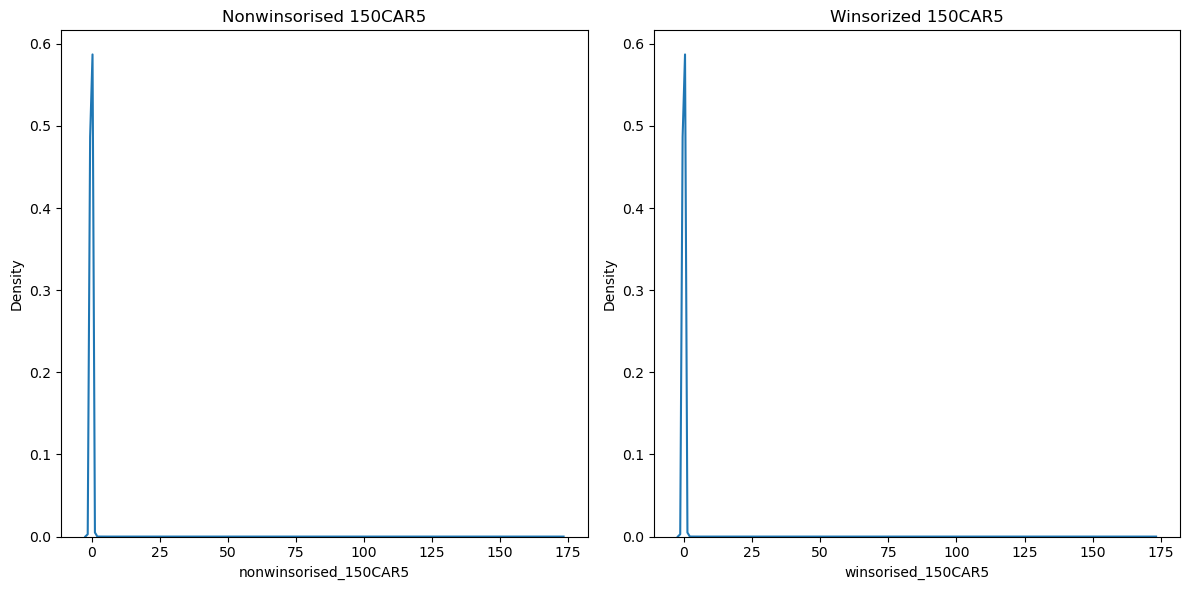

       winsorised_150CAR7  nonwinsorised_150CAR7
count         6335.000000            6335.000000
mean            -0.074035              -0.074035
std              2.167318               2.167318
min             -1.422582              -1.422582
25%             -0.159092              -0.159092
50%             -0.105325              -0.105325
75%             -0.052925              -0.052925
max            172.142993             172.142993


Top values and their count:  nonwinsorised_150CAR7
0.530379      1
0.557947      1
0.574633      2
0.617888      1
0.711893      1
0.799647      2
0.843653      2
1.332583      1
1.652475      1
172.142993    1
Name: count, dtype: int64





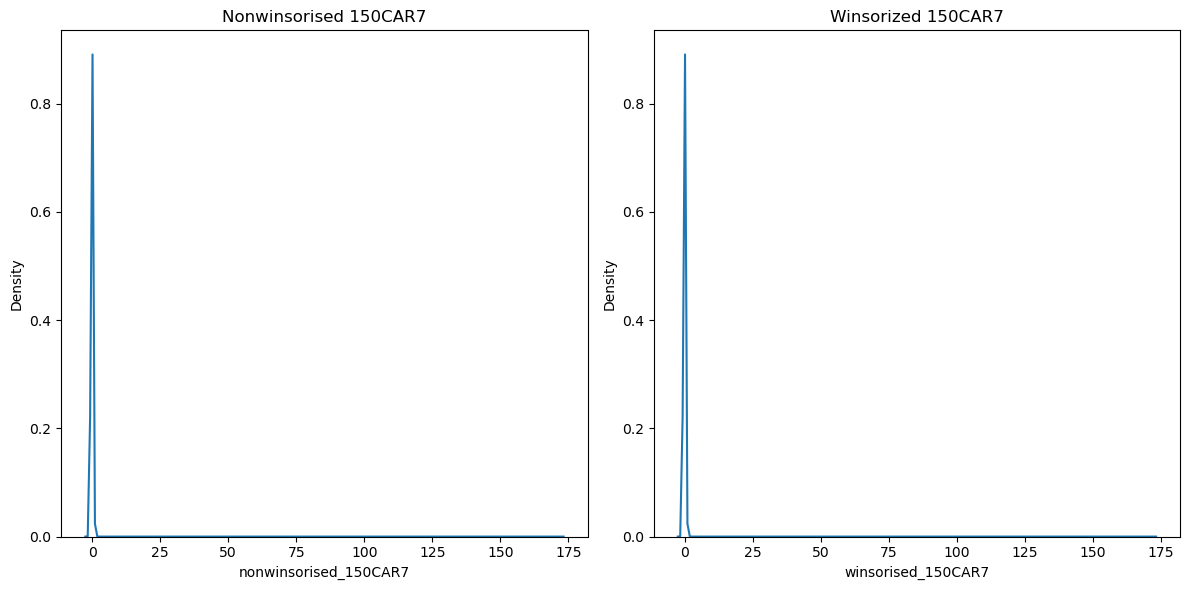

       winsorised_150CAR11  nonwinsorised_150CAR11
count          6334.000000             6334.000000
mean             -0.171737               -0.171737
std               2.170813                2.170813
min              -2.276656               -2.276656
25%              -0.277770               -0.277770
50%              -0.208273               -0.208273
75%              -0.131638               -0.131638
max             171.998645              171.998645


Top values and their count:  nonwinsorised_150CAR11
0.677050      1
0.692702      2
0.714367      1
1.014164      1
1.101002      1
1.182573      1
1.862074      2
2.019356      1
5.805956      1
171.998645    1
Name: count, dtype: int64





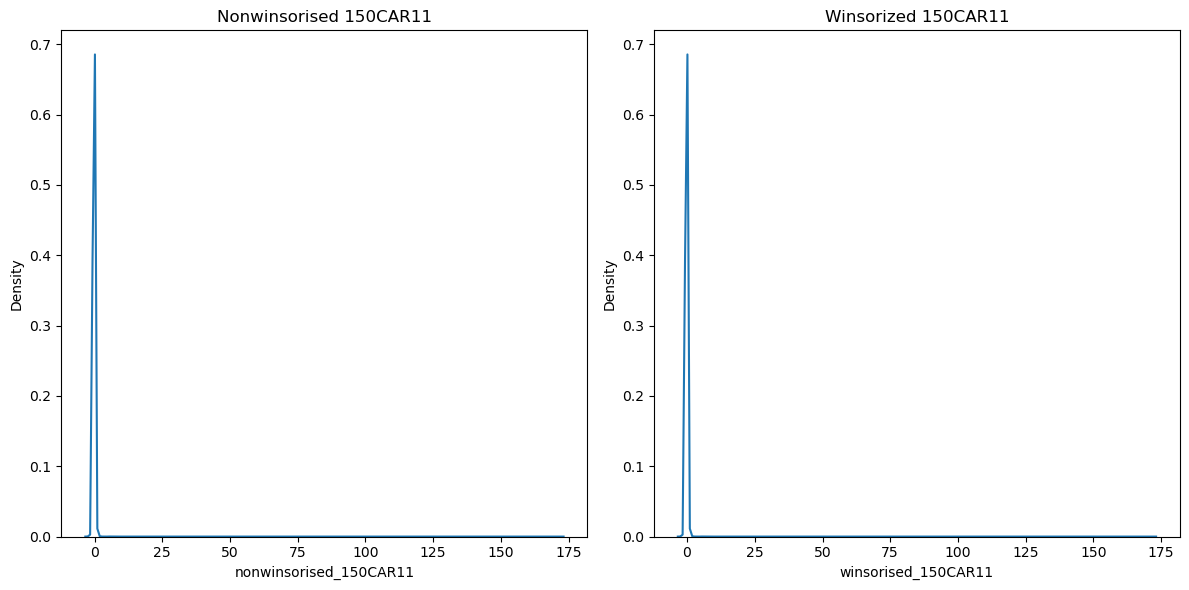

       winsorised_180CAR3  nonwinsorised_180CAR3
count         6317.000000            6317.000000
mean             0.025332               0.025332
std              2.167799               2.167799
min             -0.923095              -0.923095
25%             -0.037676              -0.037676
50%             -0.005823              -0.005823
75%              0.030512               0.030512
max            172.197104             172.197104


Top values and their count:  nonwinsorised_180CAR3
0.349389      1
0.361125      2
0.363167      1
0.389323      2
0.459640      1
0.469022      1
0.524774      1
0.584829      1
0.598306      1
172.197104    1
Name: count, dtype: int64





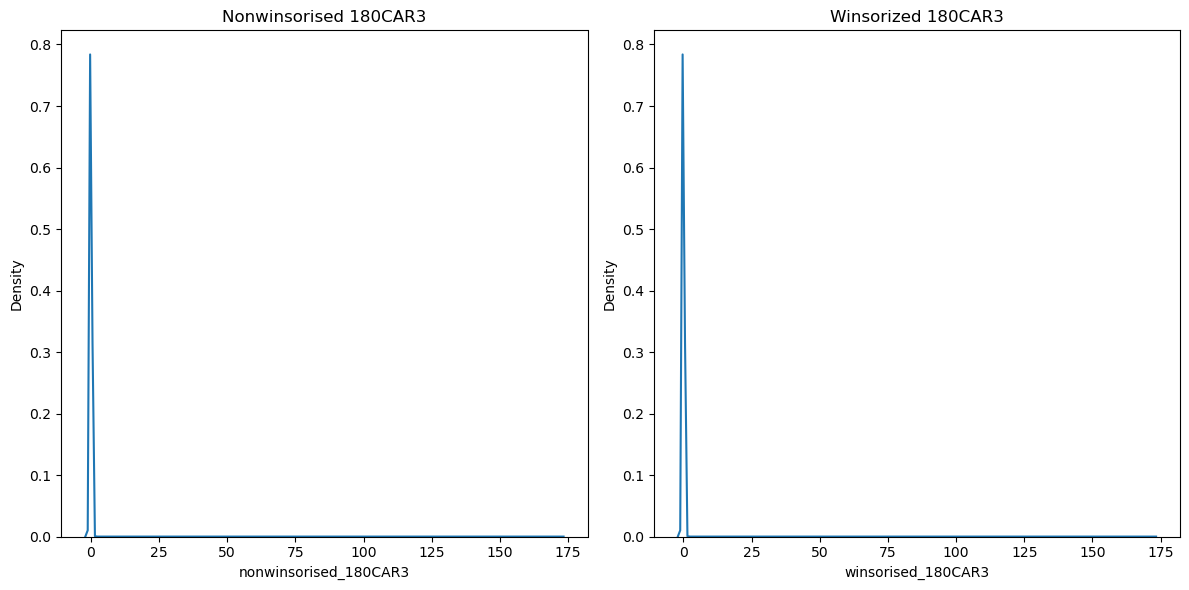

       winsorised_180CAR5  nonwinsorised_180CAR5
count         6317.000000            6317.000000
mean            -0.024983              -0.024983
std              2.169096               2.169096
min             -1.024428              -1.024428
25%             -0.096971              -0.096971
50%             -0.054676              -0.054676
75%             -0.014495              -0.014495
max            172.162883             172.162883


Top values and their count:  nonwinsorised_180CAR5
0.520253      1
0.529765      1
0.553240      2
0.654920      1
0.752163      1
0.768421      2
0.823484      1
0.872663      1
1.321390      2
172.162883    1
Name: count, dtype: int64





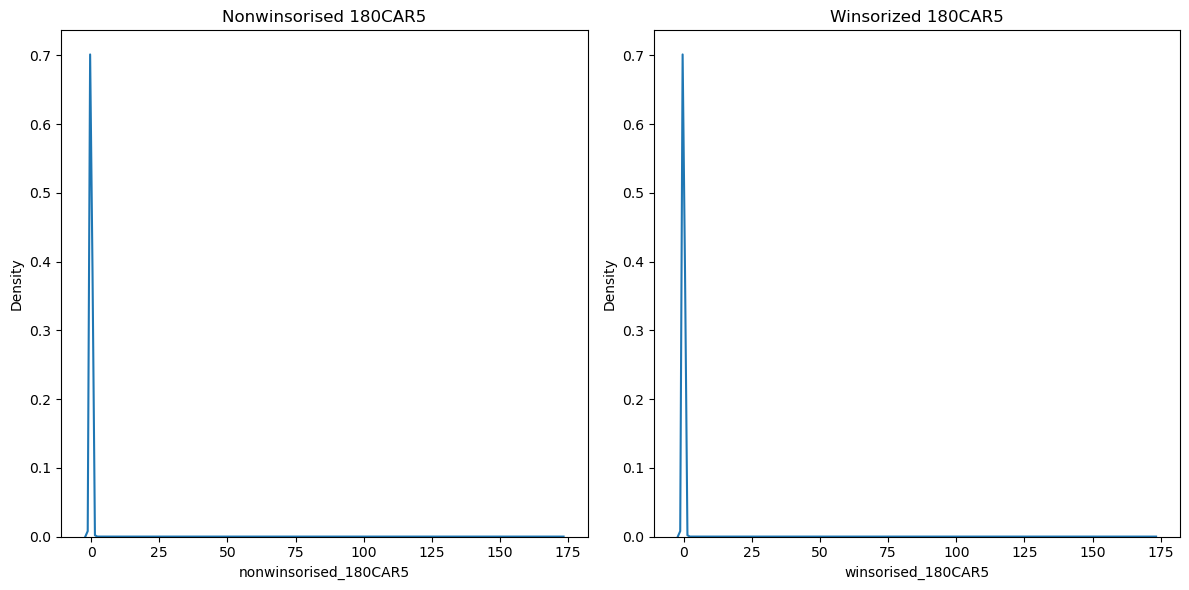

       winsorised_180CAR7  nonwinsorised_180CAR7
count         6314.000000            6314.000000
mean            -0.074098              -0.074098
std              2.170957               2.170957
min             -1.183477              -1.183477
25%             -0.158963              -0.158963
50%             -0.106459              -0.106459
75%             -0.053254              -0.053254
max            172.143403             172.143403


Top values and their count:  nonwinsorised_180CAR7
0.526580      1
0.573549      1
0.578471      2
0.617150      1
0.712493      1
0.777487      2
1.157361      2
1.333720      1
1.700582      1
172.143403    1
Name: count, dtype: int64





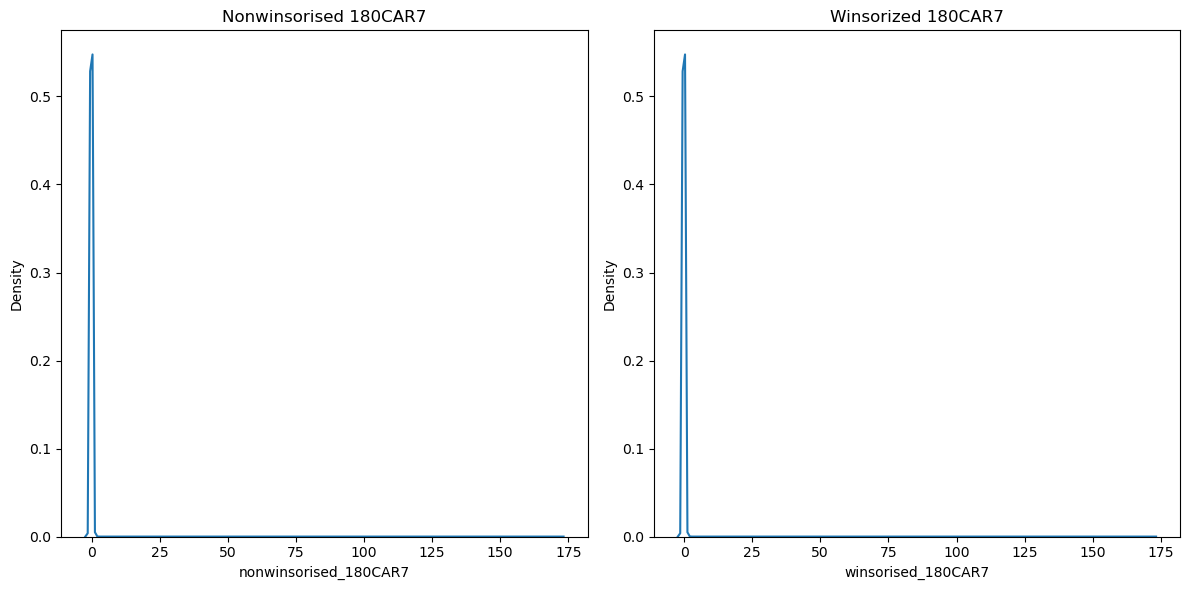

       winsorised_180CAR11  nonwinsorised_180CAR11
count          6313.000000             6313.000000
mean             -0.171521               -0.171521
std               2.174585                2.174585
min              -1.854222               -1.854222
25%              -0.277667               -0.277667
50%              -0.208650               -0.208650
75%              -0.131851               -0.131851
max             171.998783              171.998783


Top values and their count:  nonwinsorised_180CAR11
0.677057      2
0.677832      1
0.713352      1
1.023327      1
1.147810      1
1.154306      1
2.020638      1
2.561080      2
5.806742      1
171.998783    1
Name: count, dtype: int64





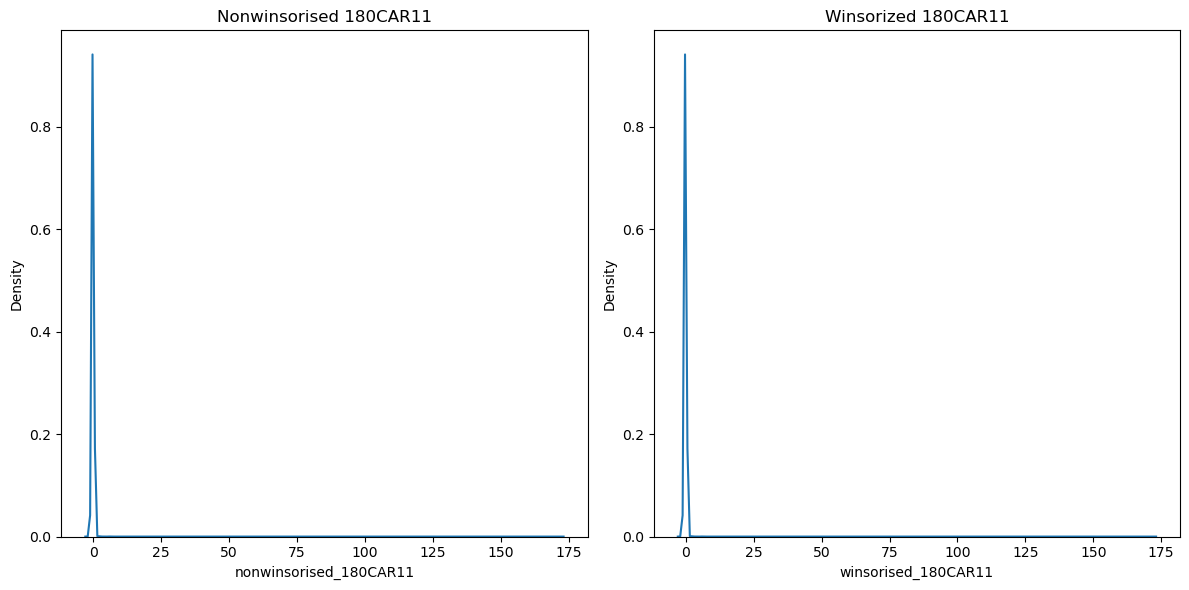

       winsorised_210CAR3  nonwinsorised_210CAR3
count         6297.000000            6297.000000
mean             0.025431               0.025431
std              2.171267               2.171267
min             -1.293352              -1.293352
25%             -0.037516              -0.037516
50%             -0.005445              -0.005445
75%              0.030544               0.030544
max            172.195614             172.195614


Top values and their count:  nonwinsorised_210CAR3
0.358083      1
0.359733      1
0.368427      2
0.395703      2
0.456135      1
0.471367      1
0.521263      1
0.585313      1
0.615202      1
172.195614    1
Name: count, dtype: int64





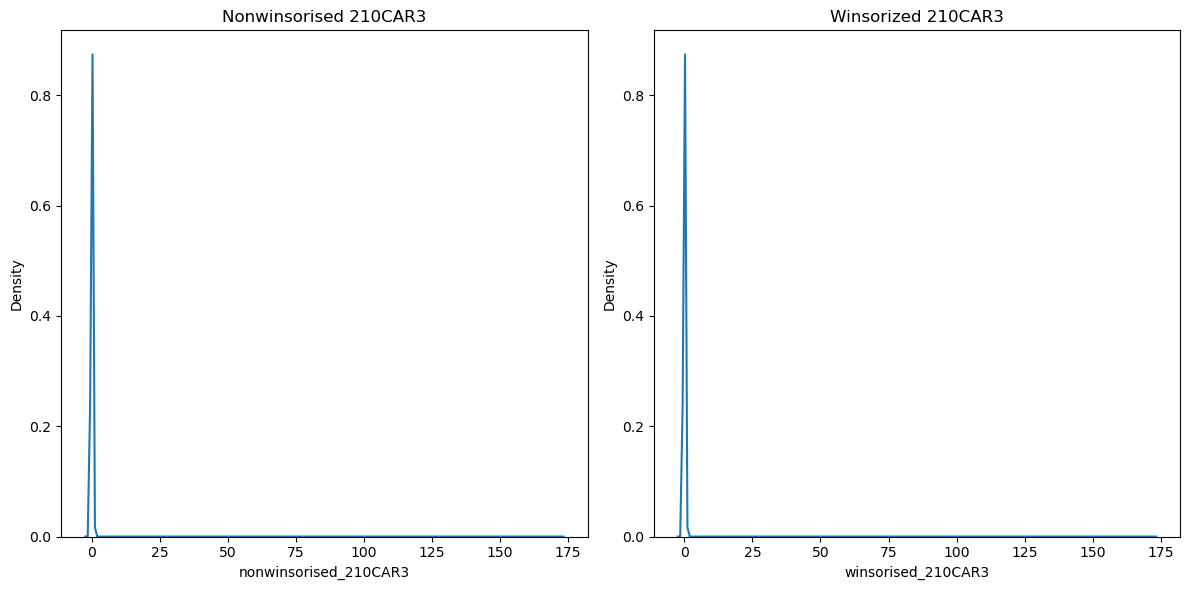

       winsorised_210CAR5  nonwinsorised_210CAR5
count         6297.000000            6297.000000
mean            -0.024852              -0.024852
std              2.172565               2.172565
min             -1.330682              -1.330682
25%             -0.097084              -0.097084
50%             -0.055042              -0.055042
75%             -0.014343              -0.014343
max            172.161688             172.161688


Top values and their count:  nonwinsorised_210CAR5
0.518387      1
0.526290      1
0.575218      2
0.671156      1
0.759265      2
0.766865      1
0.838681      1
0.872740      1
1.332876      2
172.161688    1
Name: count, dtype: int64





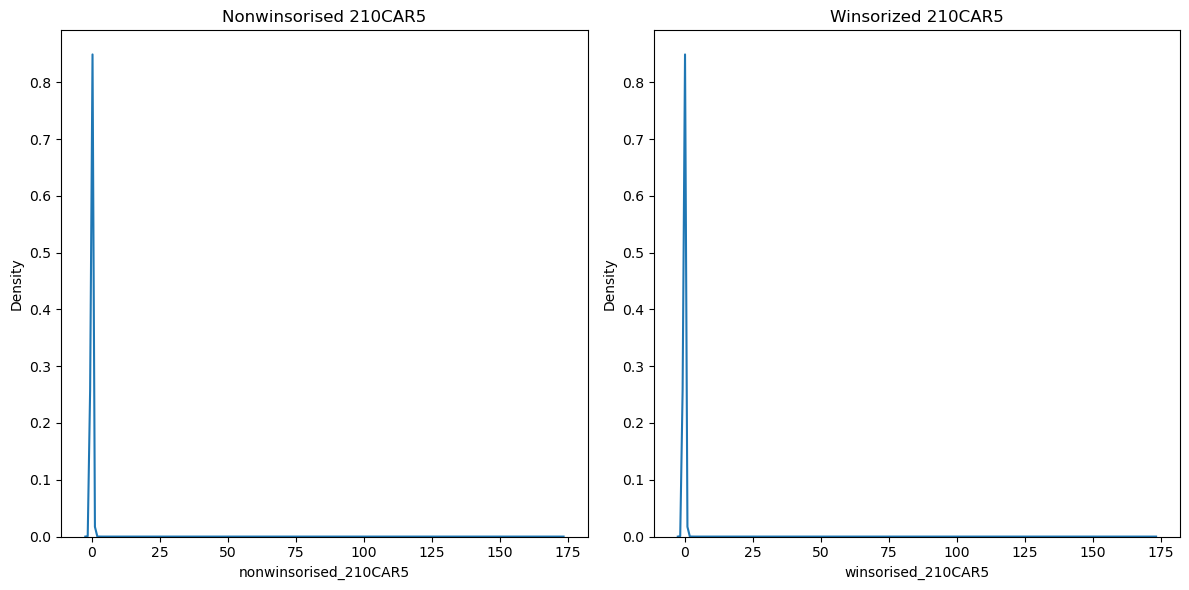

       winsorised_210CAR7  nonwinsorised_210CAR7
count         6294.000000            6294.000000
mean            -0.074128              -0.074128
std              2.174473               2.174473
min             -1.581657              -1.581657
25%             -0.159661              -0.159661
50%             -0.106401              -0.106401
75%             -0.052964              -0.052964
max            172.143482             172.143482


Top values and their count:  nonwinsorised_210CAR7
0.540097      1
0.581096      2
0.590296      1
0.617164      1
0.712379      1
0.792013      2
1.221736      2
1.334236      1
1.714716      1
172.143482    1
Name: count, dtype: int64





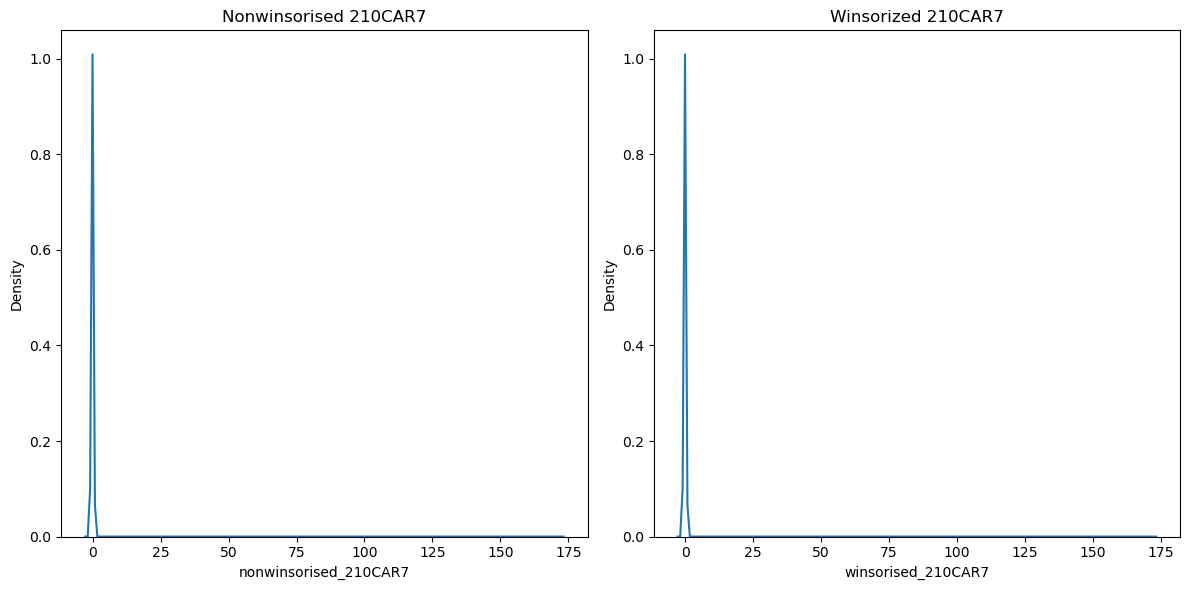

       winsorised_210CAR11  nonwinsorised_210CAR11
count          6293.000000             6293.000000
mean             -0.171463               -0.171463
std               2.178086                2.178086
min              -1.603810               -1.603810
25%              -0.277685               -0.277685
50%              -0.207996               -0.207996
75%              -0.131051               -0.131051
max             171.999371              171.999371


Top values and their count:  nonwinsorised_210CAR11
0.679068      1
0.685767      2
0.713342      1
1.042222      1
1.161674      1
1.167972      1
2.021285      1
2.694633      2
5.807275      1
171.999371    1
Name: count, dtype: int64





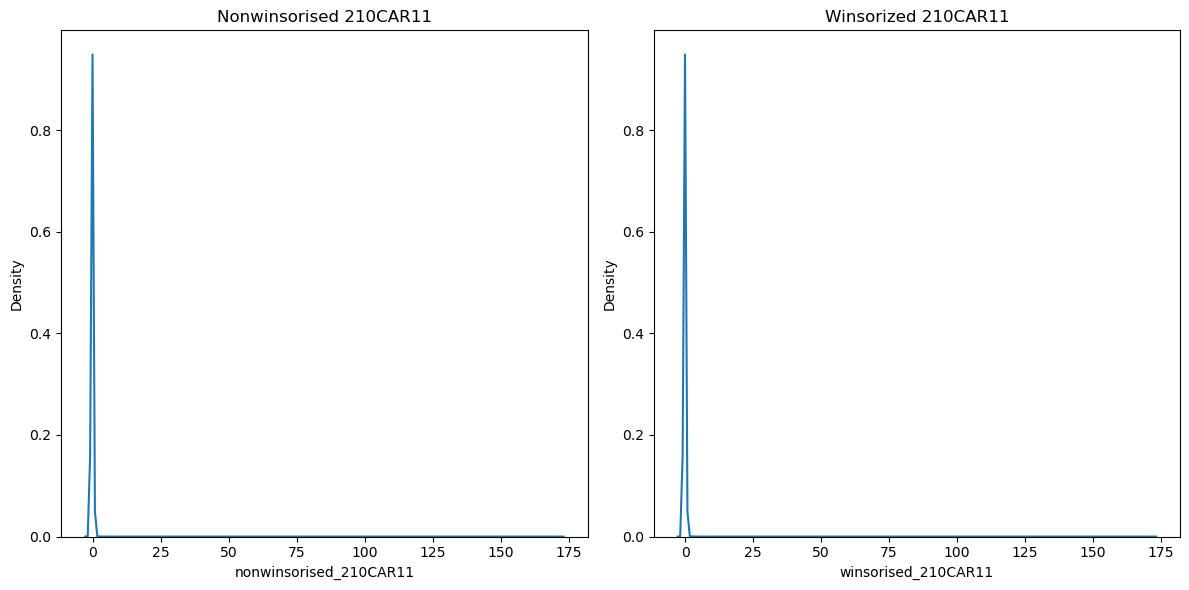

In [10]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0, 0])

In [11]:
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "PC1_FactorScore_Standardised", "ln_dirage", "ln_directorships"
# ]
# filter_datas = []
# CARs = [120, 150, 180, 210]
# for i,CAR in enumerate(CARs):
#     frame = pd. read_pickle(rf"{filtering_folder_path}\Insufficient Data for {CAR}CAR.pkl").rename({"AsOnDate":"Date"}, axis = 1)
#     filter_datas.append(frame)

# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# print("N for each CAR, no subsampling, dropping for na in control vars + car")

# event_days = [3, 5, 7, 11]

# for i,CAR in enumerate(CARs):
#     frame = psmSampleIndep.merge(filter_datas[i], left_on = ["CompanyName", "Appointment Date"], right_on = ["CompanyName", "Date"], how = "left")
#     for days in event_days:
#         car = f"{CAR}CAR{days}"
#         print(f"{car} N = ", frame.dropna(subset = [car] + controlVars)["na_trading_days"].mean() )

# frame_filtered = frame.dropna(subset=[car] + controlVars)
# frame_filtered["index"] = frame_filtered.index
# frame_filtered.plot(kind="scatter", x="index", y="na_trading_days")

In [12]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [13]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [14]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment":<20} {"Control":<20} {"SMD":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            # p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {smd:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [15]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [16]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [17]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [18]:
def prep_sample(sample, car, controlVars, yearDummy = 0, industryDummy = 0) -> tuple[pd.DataFrame, list[str]]:
    
    sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)

    if yearDummy == 1:
        yearDummies = pd.get_dummies( sample["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = yearDummies.sum().loc[ yearDummies.sum() == 1 ].index.values
        yearDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, yearDummies], axis = 1)
    else:
        yearDummies = pd.DataFrame()
    
    if industryDummy == 1:
        industryDummies = pd.get_dummies( sample["NIC_1digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = industryDummies.sum().loc[ industryDummies.sum() == 1 ].index.values
        industryDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, industryDummies], axis = 1)
    else:
        industryDummies = pd.DataFrame()

    exog_var = controlVars + yearDummies.columns.to_list() + industryDummies.columns.to_list()

    # checking for multicollinearity
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    from statsmodels.tools.tools import add_constant
    exog_with_const = add_constant(sample[exog_var])
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = exog_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(exog_with_const.values, i)
                       for i in range(exog_with_const.shape[1])]
    highCollinearity = [x for x in 
                    vif_data.loc[ vif_data["VIF"] > 10 ]["feature"].values
                    if x!="const"]
    exog_var = [x for x in exog_var if x not in highCollinearity]    
    
    return sample, exog_var

# PSM on PCA output + other controls

In [19]:
controlVars = ["PercentWomenDir", "PercentBusyDir",
               "LnBoardSize", "PercentIndep",
               "Promoters_percent", "NonpromoterInstitutions_percent",
               "ln_marcap", "ln_rdtoassets", "Debt to equity ratio"]

# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "Skilllist_FactorScore", "ln_dirage", "ln_directorships"
# ]

#PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm)

# No Higher level Filtration

## Version 0: No filtration

## No fixed effects

### PSM with replacement

In [20]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.438556
         Iterations 6


120CAR3 :


T Statistic: -1.0232013045472539  P Value: 0.3063517069571106
Treated Mean: -0.0025054514611723717  Control Mean: 0.0006655146151947328  Diff: -0.0031709660763671044
Treated Median: -0.005921136414767429  Control Median: -0.003693119976440097  Diff: -0.002228016438327332
Treated N: 894 ; Control N: 894
[treated unique =  894 ] [control unique =  623 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 894              N = 894             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1784               0.1739               0.0407          

## Using Year fixed effects

### PSM with replacement

In [21]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.431846
         Iterations 7


120CAR3 :


T Statistic: -1.5199651977386741  P Value: 0.12869709708876403
Treated Mean: -0.002510988477134777  Control Mean: 0.0022158010021035234  Diff: -0.0047267894792383
Treated Median: -0.005921136414767429  Control Median: -0.004504607941318619  Diff: -0.00141652847344881
Treated N: 894 ; Control N: 894
[treated unique =  894 ] [control unique =  614 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 894              N = 894             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1784               0.1806               -0.0200             

## Using Year + Industry fixed effects

### PSM with replacement

In [22]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.430578
         Iterations 7


120CAR3 :


T Statistic: -1.5297363366083356  P Value: 0.1262595625459906
Treated Mean: -0.002628129515304669  Control Mean: 0.0021251505462642414  Diff: -0.00475328006156891
Treated Median: -0.005921136414767429  Control Median: -0.0035229790980106437  Diff: -0.0023981573167567855
Treated N: 894 ; Control N: 894
[treated unique =  894 ] [control unique =  609 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 894              N = 894             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1784               0.1769               0.0139           

In [23]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [24]:
psmSampleIndep1 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [25]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.433780
         Iterations 7


120CAR3 :


T Statistic: -0.6766143362753202  P Value: 0.4988937517935934
Treated Mean: -0.00042696833799122925  Control Mean: 0.0032164271279384606  Diff: -0.00364339546592969
Treated Median: -0.008678800561720948  Control Median: -0.001328880291649584  Diff: -0.007349920270071364
Treated N: 325 ; Control N: 325
[treated unique =  325 ] [control unique =  226 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 325              N = 325             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1864               0.1864               0.0003           

## Using Year fixed effects

### PSM with replacement

In [26]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.421344
         Iterations 7


120CAR3 :


T Statistic: 0.2565415274846448  P Value: 0.7976142298893749
Treated Mean: -0.00017514018682683138  Control Mean: -0.0016459200789185318  Diff: 0.0014707798920917004
Treated Median: -0.008678800561720948  Control Median: -0.00469110349636416  Diff: -0.003987697065356788
Treated N: 325 ; Control N: 325
[treated unique =  325 ] [control unique =  220 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 325              N = 325             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1864               0.1836               0.0262           

## Using Year + Industry fixed effects

### PSM with replacement

In [27]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.418825
         Iterations 7


120CAR3 :


T Statistic: -1.6238502124271916  P Value: 0.10489418628160004
Treated Mean: 0.00015297368204768345  Control Mean: 0.009402730051231272  Diff: -0.00924975636918359
Treated Median: -0.008678800561720948  Control Median: 0.000437205573616567  Diff: -0.009116006135337515
Treated N: 325 ; Control N: 325
[treated unique =  325 ] [control unique =  214 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 325              N = 325             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1864               0.1964               -0.0879            

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [28]:
psmSampleIndep2 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [29]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.425248
         Iterations 6


120CAR3 :


T Statistic: -0.4905675860210223  P Value: 0.6238434300531868
Treated Mean: -0.0009172840146735999  Control Mean: 0.0009356026856330237  Diff: -0.0018528867003066237
Treated Median: -0.005261823860647621  Control Median: -0.005080607642633364  Diff: -0.00018121621801425736
Treated N: 486 ; Control N: 486
[treated unique =  486 ] [control unique =  334 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 486              N = 486             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1760               0.1756               0.0037        

## Using Year fixed effects

### PSM with replacement

In [30]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.418225
         Iterations 7


120CAR3 :


T Statistic: 0.6884457917182153  P Value: 0.49133709510644985
Treated Mean: -0.0017867611758098712  Control Mean: -0.004478114218761196  Diff: 0.0026913530429513244
Treated Median: -0.005261823860647621  Control Median: -0.006295633882469266  Diff: 0.0010338100218216448
Treated N: 486 ; Control N: 486
[treated unique =  486 ] [control unique =  336 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 486              N = 486             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1760               0.1724               0.0347           

## Using Year + Industry fixed effects

### PSM with replacement

In [31]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.416939
         Iterations 7


120CAR3 :


T Statistic: 0.21797722531081934  P Value: 0.8274927650322423
Treated Mean: -0.0017722174149599273  Control Mean: -0.0026296485148172314  Diff: 0.0008574310998573041
Treated Median: -0.005261823860647621  Control Median: -0.0034536947074967628  Diff: -0.0018081291531508586
Treated N: 486 ; Control N: 486
[treated unique =  486 ] [control unique =  341 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 486              N = 486             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1760               0.1811               -0.0463       

In [32]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Higher level Filteration: DUPLICATED DIRECTORS REMOVED

## Version 0: No filtration

In [33]:
# psmSampleIndep0 = psmSampleIndep.copy()

# yearDummies0 = pd.get_dummies( psmSampleIndep0["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearDummies0 = pd.concat([psmSampleIndep0, yearDummies0], axis = 1)

# industryDummies0 = pd.get_dummies( psmSampleIndep0["NIC_2digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearIndustryDummies0 = pd.concat([psmSampleIndepWithYearDummies0, industryDummies0], axis = 1)

# depVar = None

In [34]:
duplicated = psmSampleIndep.duplicated(subset = ["Symbol", "Appointment Date"], keep = False).to_frame("val")
filtered_index = duplicated.loc[duplicated["val"] == False].index
psmSampleIndep_filtered = psmSampleIndep.loc[filtered_index].copy()

## No fixed effects

### PSM with replacement

In [35]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.436103
         Iterations 6


120CAR3 :


T Statistic: -0.6410564957582084  P Value: 0.5215991172293393
Treated Mean: -0.0021570564693635568  Control Mean: 0.00017341822477048616  Diff: -0.002330474694134043
Treated Median: -0.006829577512385526  Control Median: -0.003640354609606336  Diff: -0.00318922290277919
Treated N: 651 ; Control N: 651
[treated unique =  651 ] [control unique =  469 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 651              N = 651             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1777               0.1826               -0.0454          

## Using Year fixed effects

### PSM with replacement

In [36]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.427309
         Iterations 7


120CAR3 :


T Statistic: -1.2004480455580333  P Value: 0.2301860025543884
Treated Mean: -0.002221441828540881  Control Mean: 0.0019271973699264413  Diff: -0.004148639198467322
Treated Median: -0.006829577512385526  Control Median: -0.0034536947074967628  Diff: -0.0033758828048887635
Treated N: 651 ; Control N: 651
[treated unique =  651 ] [control unique =  466 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 651              N = 651             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1777               0.1740               0.0339          

## Using Year + Industry fixed effects

### PSM with replacement

In [37]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.426632
         Iterations 7


120CAR3 :


T Statistic: -0.0018794293057320145  P Value: 0.9985007220034365
Treated Mean: -0.002818314749845077  Control Mean: -0.002811597436109715  Diff: -6.717313735361743e-06
Treated Median: -0.006829577512385526  Control Median: -0.0033266878914926384  Diff: -0.003502889620892888
Treated N: 651 ; Control N: 651
[treated unique =  651 ] [control unique =  471 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 651              N = 651             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1777               0.1809               -0.0291      

In [38]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [39]:
psmSampleIndep1 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [40]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.437416
         Iterations 7


120CAR3 :


T Statistic: -0.2027191185776843  P Value: 0.839441202174318
Treated Mean: -0.00035466514718312825  Control Mean: 0.000993574125843841  Diff: -0.0013482392730269693
Treated Median: -0.006829577512385526  Control Median: -0.00827691041312914  Diff: 0.0014473329007436142
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  170 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1867               -0.0158           

## Using Year fixed effects

### PSM with replacement

In [41]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.421023
         Iterations 7


120CAR3 :


T Statistic: 0.4905081201675837  P Value: 0.6240054562447499
Treated Mean: -0.0006313263451355821  Control Mean: -0.003590655363676257  Diff: 0.0029593290185406748
Treated Median: -0.006829577512385526  Control Median: -0.01450189237532977  Diff: 0.007672314862944243
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  178 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1817               0.0289              

## Using Year + Industry fixed effects

### PSM with replacement

In [42]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.417742
         Iterations 7


120CAR3 :


T Statistic: -0.7332322166092584  P Value: 0.46378357253353875
Treated Mean: -0.0002292160933245652  Control Mean: 0.0043294840940164255  Diff: -0.0045587001873409905
Treated Median: -0.006829577512385526  Control Median: -0.0008759241735554063  Diff: -0.00595365333883012
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  172 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1948               -0.0854        

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [43]:
psmSampleIndep2 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [44]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.420469
         Iterations 6


120CAR3 :


T Statistic: -1.0821047780797624  P Value: 0.27957859644438465
Treated Mean: -0.0004758473962993807  Control Mean: 0.004379309155631643  Diff: -0.004855156551931024
Treated Median: -0.005723981926652966  Control Median: -0.0026434968338380077  Diff: -0.003080485092814958
Treated N: 351 ; Control N: 351
[treated unique =  351 ] [control unique =  254 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 351              N = 351             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1738               0.1790               -0.0502         

## Using Year fixed effects

### PSM with replacement

In [45]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.411122
         Iterations 7


120CAR3 :


T Statistic: 0.8393429461441981  P Value: 0.40156406946441814
Treated Mean: -0.0008076894961502382  Control Mean: -0.004433055350789885  Diff: 0.0036253658546396466
Treated Median: -0.005723981926652966  Control Median: -0.008522311518763065  Diff: 0.0027983295921100992
Treated N: 351 ; Control N: 351
[treated unique =  351 ] [control unique =  260 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 351              N = 351             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1738               0.1764               -0.0247          

## Using Year + Industry fixed effects

### PSM with replacement

In [46]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.410795
         Iterations 7


120CAR3 :


T Statistic: -0.4832855939041152  P Value: 0.6290451259985326
Treated Mean: -0.0007506184912852857  Control Mean: 0.001307596007044911  Diff: -0.0020582144983301966
Treated Median: -0.005723981926652966  Control Median: -0.0034536947074967628  Diff: -0.002270287219156203
Treated N: 351 ; Control N: 351
[treated unique =  351 ] [control unique =  248 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 351              N = 351             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1738               0.1712               0.0244          

In [47]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 3: Non family firms promoterholding25==0 & hasfamilychairmanandceo==0

In [48]:
psmSampleIndep3 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==0) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [49]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.519080
         Iterations 6


120CAR3 :


T Statistic: -0.7848453196272114  P Value: 0.43489712098049427
Treated Mean: -0.0047684426999022814  Control Mean: 0.010105527215612762  Diff: -0.014873969915515043
Treated Median: 0.009229079849128043  Control Median: 0.02008911882857478  Diff: -0.010860038979446738
Treated N: 42 ; Control N: 42
[treated unique =  42 ] [control unique =  31 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 42               N = 42              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1830               0.1846               -0.0118             
Per

## Using Year fixed effects

### PSM with replacement

In [50]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.479093
         Iterations 6


120CAR3 :


T Statistic: -0.8172385112917804  P Value: 0.41691429277521896
Treated Mean: -0.0047684426999022814  Control Mean: 0.008798707756901555  Diff: -0.013567150456803836
Treated Median: 0.009229079849128043  Control Median: 0.0171249775828534  Diff: -0.007895897733725357
Treated N: 42 ; Control N: 42
[treated unique =  42 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 42               N = 42              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1830               0.1575               0.1973              
Perc

## Using Year + Industry fixed effects

### PSM with replacement

In [51]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.477366
         Iterations 6


120CAR3 :


T Statistic: -0.6881490793302338  P Value: 0.4938243844689174
Treated Mean: -0.0047684426999022814  Control Mean: 0.00682499849525233  Diff: -0.01159344119515461
Treated Median: 0.009229079849128043  Control Median: 0.010825181092078546  Diff: -0.0015961012429505025
Treated N: 42 ; Control N: 42
[treated unique =  42 ] [control unique =  27 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 42               N = 42              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1830               0.1543               0.2135              
Perc

In [52]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 4: Rookie in Family firms vs Rookie in non family firms, family firms => promoterholding25 == 1, HasFamilyChairmanAndCEO == 1; non family ==0 for both

IMPORTANT NOTE!!!!!!!!!!!!
promoters_percent resulted in singular matrices and therefore has been removed from the covariates

In [53]:
filtered = psmSampleIndep_filtered.loc[ psmSampleIndep_filtered["IsRookieIndep"] == 1].copy()

filtered["familyfirm_dummy"] = np.where((filtered["promoterholding25"]==1) & (filtered["HasFamilyChairmanAndCEO"]==1),
                                                1,0)
filtered["nonfamilyfirm_dummy"] = np.where((filtered["promoterholding25"]==0) & (filtered["HasFamilyChairmanAndCEO"]==0),
                                                1,0)
                                                
psmSampleIndep3 = filtered.loc[ ((filtered["familyfirm_dummy"] == 1) | 
                                 (filtered["nonfamilyfirm_dummy"] == 1))].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [54]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 0, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.393398
         Iterations 7


120CAR3 :


T Statistic: -1.594128113793715  P Value: 0.11163623566487398
Treated Mean: -0.0010556633140284366  Control Mean: 0.011325693833010596  Diff: -0.012381357147039033
Treated Median: -0.006829577512385526  Control Median: 0.04237633501679472  Diff: -0.049205912529180246
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  29 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1905               -0.0483             


## Using Year fixed effects

### PSM with replacement

In [55]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.368362
         Iterations 7


120CAR3 :


T Statistic: -2.414994952020037  P Value: 0.016114656747143484
Treated Mean: -0.0010556633140284366  Control Mean: 0.015269940108269197  Diff: -0.016325603422297632
Treated Median: -0.006829577512385526  Control Median: 0.02231030917267432  Diff: -0.029139886685059846
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  30 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1439               0.3859              

## Using Year + Industry fixed effects

### PSM with replacement

In [56]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 1)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.361973
         Iterations 7


120CAR3 :


T Statistic: -0.8553038645503226  P Value: 0.39288620593884604
Treated Mean: -0.0010556633140284366  Control Mean: 0.006122321737152657  Diff: -0.007177985051181094
Treated Median: -0.006829577512385526  Control Median: 0.02231030917267432  Diff: -0.029139886685059846
Treated N: 239 ; Control N: 239
[treated unique =  239 ] [control unique =  29 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 239              N = 239             
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1849               0.1852               -0.0021             

In [57]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

In [58]:
# endog_var = "familyfirm_dummy"
# endog = sample[[endog_var]]
# exog = sample[[x for x in exog_var if x != "Promoters_percent"]]
# exog = sm.add_constant(exog)

# log_reg = sm.Logit(endog, exog).fit()

# propensityScores = log_reg.predict(exog)

# sample[["Promoters_percent", "familyfirm_dummy"]]

# pd.crosstab(sample["Promoters_percent"], sample["familyfirm_dummy"])

# exog_var